# 03 — Funnel Analysis
### *"Where are we losing orders?"*

**Dataset:** the real [Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) Brazilian
e-commerce dataset. Every number below is computed from the curated `orders` table — nothing is typed
by hand.

> **The honest framing.** A classic funnel analysis tracks a *web* clickstream: `view → cart →
> checkout → pay`. Olist ships **no clickstream** — we only see orders that were actually placed. So
> "where are we losing orders?" has to be answered with the two funnels the data *does* support:
>
> 1. the **order-lifecycle funnel** — the status pipeline every order walks
>    (`created → approved → invoiced → processing → shipped → delivered`), and
> 2. the **delivery funnel** — of the orders that ship, how many arrive *on time*.
>
> The punchline, established below: the lifecycle funnel barely leaks — ~98% of orders complete. The
> real loss isn't cancellation, it's **late delivery**, and it is not spread evenly.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analytics import config, metrics, transform

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titleweight": "bold"})
BLUE, LT = "#2563eb", "#93c5fd"
RED = "#dc2626"

assert config.ORDERS.exists(), "Run `python -m analytics.build` first (see README)."
orders = pd.read_parquet(config.ORDERS)
delivered = orders[orders.is_delivered]
print(f"orders={len(orders):,}   delivered={len(delivered):,}")

orders=99,441   delivered=96,478


## 1. The order-lifecycle funnel

`metrics.status_funnel` builds a true *monotonic* funnel: a delivered order necessarily passed
approval, invoicing, processing and shipping, so each stage counts "orders that reached **at least**
this far." The funnel is defined over the six pipeline statuses only — terminal `canceled` and
`unavailable` orders fall out of the pipeline entirely and are counted separately in section 2.

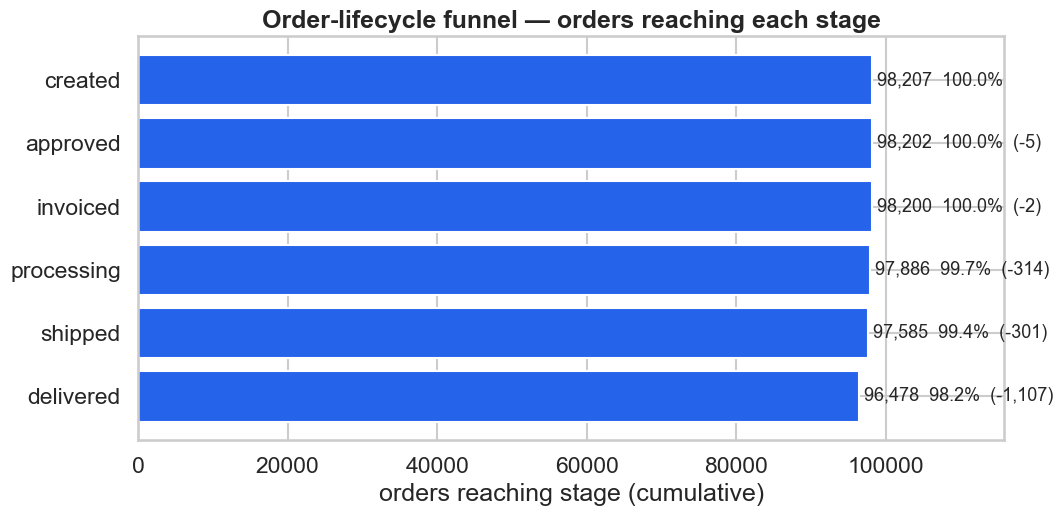

,stage,orders,pct_of_top
0,created,98207,100.0
1,approved,98202,100.0
2,invoiced,98200,100.0
3,processing,97886,99.7
4,shipped,97585,99.4
5,delivered,96478,98.2


In [2]:
funnel = metrics.status_funnel(orders)
top = funnel.orders.iloc[0]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(funnel.stage, funnel.orders, color=BLUE)
ax.invert_yaxis()
for i, (n, pct) in enumerate(zip(funnel.orders, funnel.pct_of_top)):
    drop = "" if i == 0 else f"  (-{funnel.orders.iloc[i-1]-n:,})"
    ax.text(n, i, f" {n:,}  {pct:.1f}%{drop}", va="center", fontsize=13)
ax.set_xlim(0, top*1.18)
ax.set_title("Order-lifecycle funnel — orders reaching each stage")
ax.set_xlabel("orders reaching stage (cumulative)")
plt.tight_layout(); plt.show()
funnel

**Read:** the pipeline is remarkably tight. Of **98,207** orders that enter it, **96,478 reach
`delivered` — a 98.2% completion rate.** The only visible step-downs are small: ~0.3% drop out at
`processing`, another ~0.3% at `shipped`, and ~1.1% are stuck at `shipped` without a delivery
confirmation. There is **no cliff** anywhere in the status pipeline. A funnel this flat is telling us
the loss we care about is *not* here — it's downstream, in whether the delivery lands on time.

## 2. Where the orders that *don't* deliver actually die

98.2% is the completion rate *within* the pipeline. Stepping back to all **99,441** orders, which ones
never reach the customer, and why? We split the non-delivered orders into **terminal** outcomes
(`canceled`, `unavailable` — the order is dead) versus **in-flight** statuses (`shipped`, `invoiced`,
`processing`, …) that are simply mid-pipeline at the dataset's snapshot date.

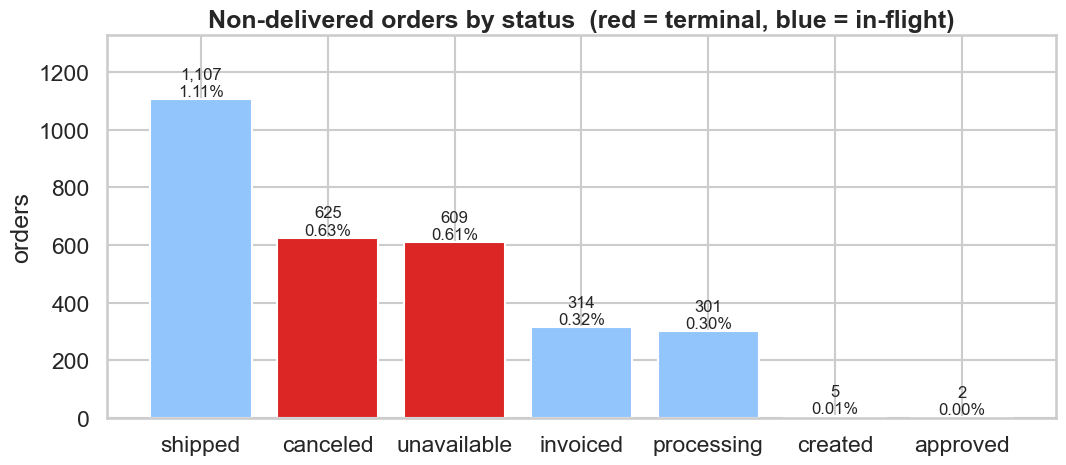

Non-delivered total: 2,963 (2.98% of all orders)
Truly dead (canceled+unavailable): 1,234 (1.24%)


,orders,pct
order_status,,
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


In [3]:
nd = orders[orders.order_status != "delivered"].order_status.value_counts()
terminal = ["canceled", "unavailable"]
kind = ["terminal" if s in terminal else "in-flight" for s in nd.index]
colors = [RED if k == "terminal" else LT for k in kind]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(nd.index, nd.values, color=colors)
for b, v in zip(bars, nd.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}\n{v/len(orders)*100:.2f}%", ha="center", va="bottom", fontsize=12)
ax.set_title("Non-delivered orders by status  (red = terminal, blue = in-flight)")
ax.set_ylabel("orders"); ax.set_ylim(0, nd.max()*1.2)
plt.tight_layout(); plt.show()

dead = orders.order_status.isin(terminal).sum()
print(f"Non-delivered total: {nd.sum():,} ({nd.sum()/len(orders)*100:.2f}% of all orders)")
print(f"Truly dead (canceled+unavailable): {dead:,} ({dead/len(orders)*100:.2f}%)")
nd.to_frame("orders").assign(pct=lambda d: (d.orders/len(orders)*100).round(2))

**Read:** only **2,963 orders (2.98%)** are non-delivered at all, and most of those are *in-flight*,
not lost — 1,107 `shipped` and a few hundred each in `invoiced`/`processing` are simply orders that
hadn't completed when the data was cut. The genuinely **dead** orders — `canceled` (625) plus
`unavailable` (609) — are just **1,234 orders, 1.24% of the platform.** Cancellation is a rounding
error here. Whatever is hurting Olist, it is *not* orders failing to complete.

## 3. The delivery funnel — the leak that actually matters

Now the second funnel. Take every order, follow it to `delivered`, then split delivered orders into
**on-time** vs **late** using the curated `is_late` flag (late = arrived after the estimated delivery
date). This is where the real drop-off lives.

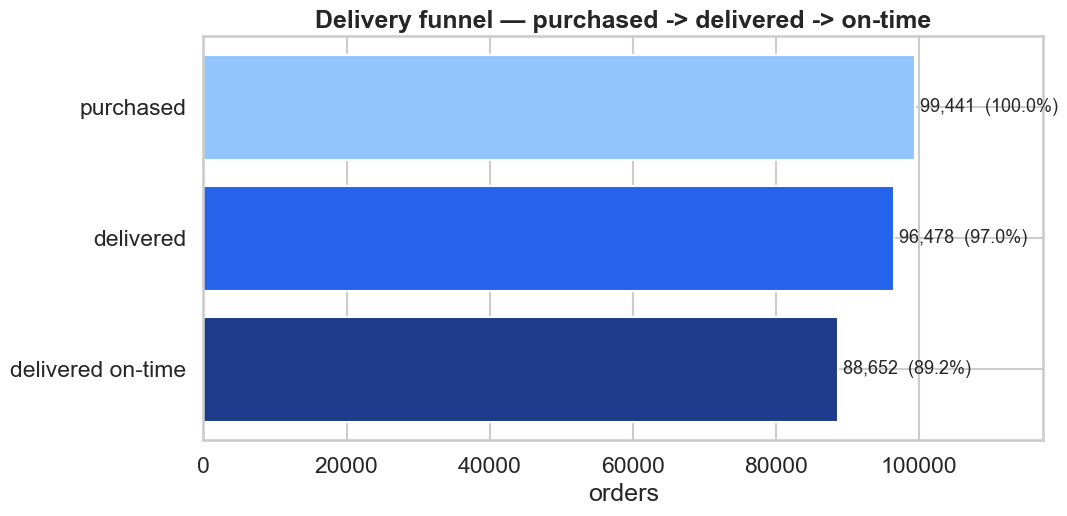

Delivered: 96,478   on-time: 88,652 (91.89%)   late: 7,826 (8.11%)


In [4]:
late = int(delivered.is_late.sum())
ontime = len(delivered) - late
stages = ["purchased", "delivered", "delivered on-time"]
vals = [len(orders), len(delivered), ontime]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(stages, vals, color=[LT, BLUE, "#1e3a8a"])
ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:,}  ({v/len(orders)*100:.1f}%)", va="center", fontsize=13)
ax.set_xlim(0, len(orders)*1.18)
ax.set_title("Delivery funnel — purchased -> delivered -> on-time")
ax.set_xlabel("orders")
plt.tight_layout(); plt.show()
print(f"Delivered: {len(delivered):,}   on-time: {ontime:,} ({ontime/len(delivered)*100:.2f}%)   "
      f"late: {late:,} ({late/len(delivered)*100:.2f}%)")

**Read:** here is the leak. Of the **96,478 delivered orders, 7,826 (8.1%) arrived late** — the
overall on-time rate is **91.9%.** That ~8% is an order of magnitude larger than the 1.24% that get
canceled, and unlike a cancellation, a late delivery still charges the customer and *then* disappoints
them. This is the drop-off worth chasing, and notebook 06 will show it is the single biggest driver of
1-star reviews.

## 4. Time-in-stage — how long delivery actually takes

The lifecycle table has no per-stage approval timestamps, but it does carry the one duration that
matters: `delivery_days` (purchase → arrival at customer). We plot its distribution against the
*promised* window (`estimated_days`, purchase → estimated delivery date) to see both the typical wait
and the tail that generates the late orders.

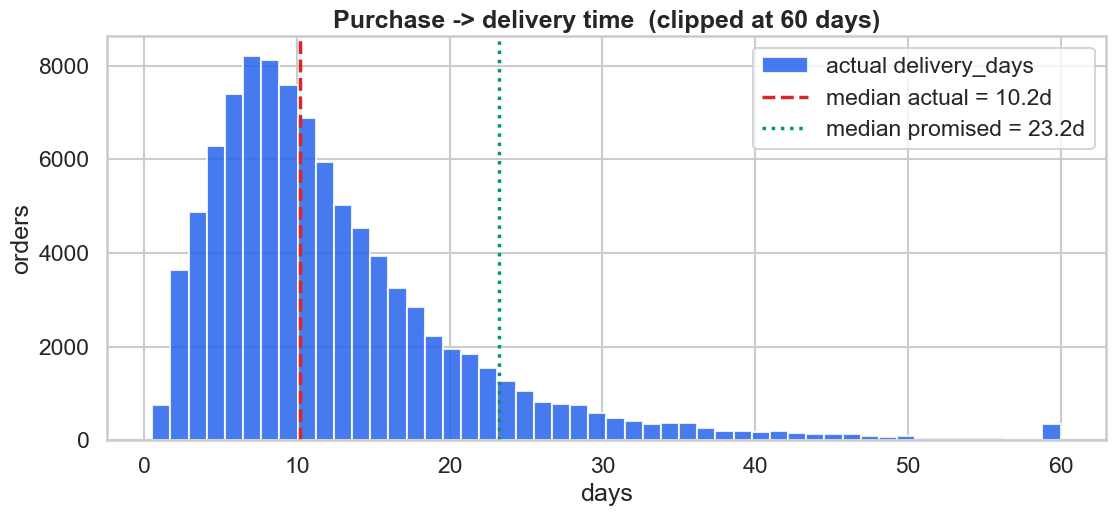

delivery_days  median=10.2  mean=12.6  p90=23.1  max=210
estimated_days median=23.2  (Olist quotes a deliberately padded window)


In [5]:
dd = delivered.delivery_days.dropna()
ed = delivered.estimated_days.dropna()
med_d, med_e = dd.median(), ed.median()

fig, ax = plt.subplots(figsize=(11.5, 5.5))
ax.hist(dd.clip(upper=60), bins=50, color=BLUE, alpha=.85, label="actual delivery_days")
ax.axvline(med_d, color=RED, lw=2.5, ls="--", label=f"median actual = {med_d:.1f}d")
ax.axvline(med_e, color="#059669", lw=2.5, ls=":", label=f"median promised = {med_e:.1f}d")
ax.set_title("Purchase -> delivery time  (clipped at 60 days)")
ax.set_xlabel("days"); ax.set_ylabel("orders"); ax.legend()
plt.tight_layout(); plt.show()
print(f"delivery_days  median={dd.median():.1f}  mean={dd.mean():.1f}  p90={dd.quantile(.9):.1f}  max={dd.max():.0f}")
print(f"estimated_days median={ed.median():.1f}  (Olist quotes a deliberately padded window)")

**Read:** the typical order arrives in a **median of ~10 days**, but the distribution has a long
right tail — the mean is dragged to ~12.6 days and the 90th percentile is **~23 days**, with a handful
of orders taking 100+ days. Crucially, the **promised** window (green, median ~24 days) sits far to the
right of the actual median: Olist pads its estimates heavily, so on-time is usually easy — which makes
the 8% that *still* miss the padded promise all the more meaningful. The lateness lives entirely in
that fat right tail, and the next section shows where it clusters.

## 5. The funnel is not uniform — lateness by geography

Notebook 01 showed demand is lopsided toward São Paulo. That skew drives this: an order to a distant
state travels much farther over Brazil's road network. We compare **late-delivery rate by customer
state** (states with ≥500 delivered orders) and, alongside it, the terminal cancel/unavailable rate to
confirm the *loss* is delivery, not cancellation.

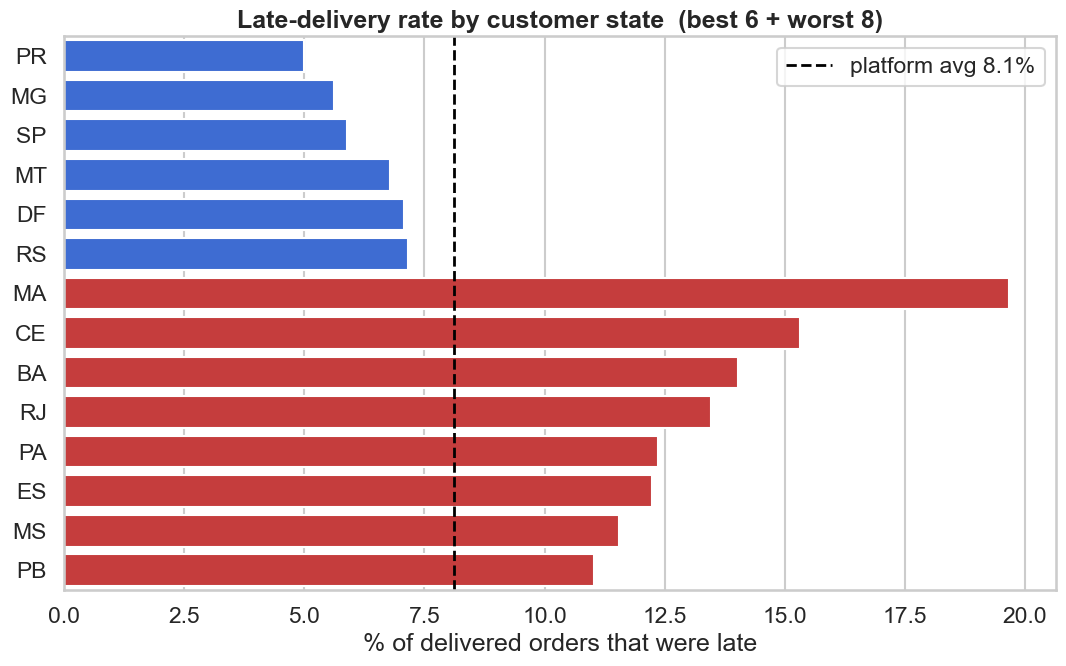

Best : PR 5.0%, MG 5.6%, SP 5.9%
Worst: BA 14.0%, CE 15.3%, MA 19.7%


In [6]:
g = (delivered.groupby("customer_state")
     .agg(late=("is_late", "mean"), n=("is_late", "size")))
g = g[g.n >= 500].sort_values("late")
overall_late = delivered.is_late.mean()
worst = g.tail(8)
best = g.head(6)
show = pd.concat([best, worst.iloc[::-1]])

fig, ax = plt.subplots(figsize=(11, 7))
cols = [RED if v > overall_late else BLUE for v in show.late]
sns.barplot(x=show.late*100, y=show.index, palette=cols, ax=ax)
ax.axvline(overall_late*100, color="black", ls="--", lw=2, label=f"platform avg {overall_late*100:.1f}%")
ax.set_title("Late-delivery rate by customer state  (best 6 + worst 8)")
ax.set_xlabel("% of delivered orders that were late"); ax.set_ylabel(""); ax.legend()
plt.tight_layout(); plt.show()
print("Best :", ", ".join(f"{s} {v*100:.1f}%" for s, v in g.head(3).late.items()))
print("Worst:", ", ".join(f"{s} {v*100:.1f}%" for s, v in g.tail(3).late.items()))

**Read:** the funnel bends hard on geography. The core southeast — **PR (5.0%), MG (5.6%), SP
(5.9%)** — delivers late on well under 1 order in 15, comfortably below the 8.1% platform line. The
northern and northeastern states blow past it: **Maranhão (MA) is late 19.7% of the time**, followed by
**Ceará (15.3%)**, **Bahia (14.0%)** and **Rio de Janeiro (13.5%)**. A customer in MA is **~4x** more
likely to receive a late order than one in PR. The delivery leak isn't a platform-wide constant — it's
concentrated in the long-haul destinations far from the São Paulo seller base.

## 6. Second segmentation — lateness rises with freight cost

Distance shows up in the data another way: heavier / farther shipments cost more freight. If lateness
tracks distance, it should track freight too. We bucket delivered orders into freight-cost quartiles
and read off the late rate per bucket — a clean, independent confirmation of the geography story.

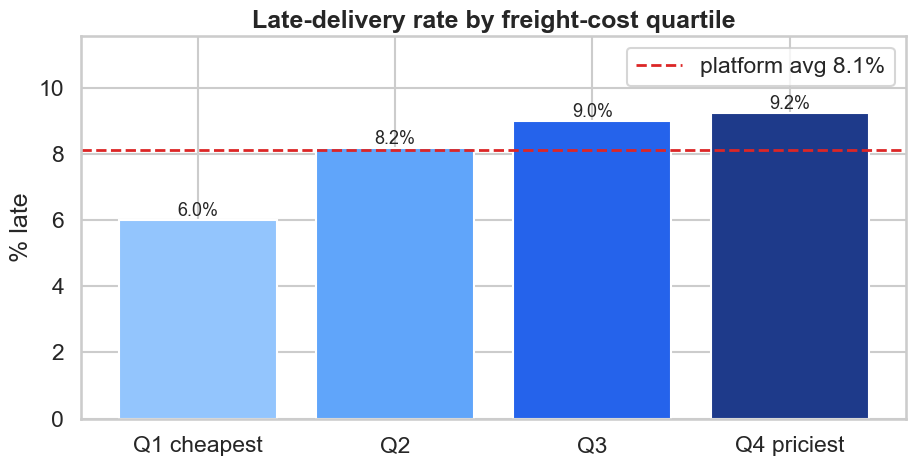

{'Q1 cheapest': 6.0, 'Q2': 8.2, 'Q3': 9.0, 'Q4 priciest': 9.2}


In [7]:
d2 = delivered.dropna(subset=["freight_value"]).copy()
d2["fq"] = pd.qcut(d2.freight_value, 4, labels=["Q1 cheapest", "Q2", "Q3", "Q4 priciest"])
fr = d2.groupby("fq", observed=True).is_late.mean() * 100

fig, ax = plt.subplots(figsize=(9.5, 5))
bars = ax.bar(fr.index.astype(str), fr.values, color=[LT, "#60a5fa", BLUE, "#1e3a8a"])
for b, v in zip(bars, fr.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=13)
ax.axhline(delivered.is_late.mean()*100, color=RED, ls="--", lw=2, label="platform avg 8.1%")
ax.set_title("Late-delivery rate by freight-cost quartile")
ax.set_ylabel("% late"); ax.set_ylim(0, fr.max()*1.25); ax.legend()
plt.tight_layout(); plt.show()
print(fr.round(1).to_dict())

**Read:** the gradient is monotonic — late rate climbs from **6.0% in the cheapest-freight quartile
to 9.2% in the priciest**, a ~50% relative jump. Freight cost is a proxy for distance and parcel size,
so this is the geography finding seen from a second angle: the farther and bulkier the shipment, the
more likely it misses its window. Two independent cuts point at the same root cause — **long-haul
logistics, not the order pipeline.**

## 7. When the funnel leaks — the backlog months

Lateness also has a *time* dimension. On-time rate is stable most months, then collapses in a few — the
signature of a fulfilment backlog outrunning capacity. We pull monthly on-time rate from
`metrics.monthly_metrics` (which already restricts to the clean analysis window) and flag the worst
months.

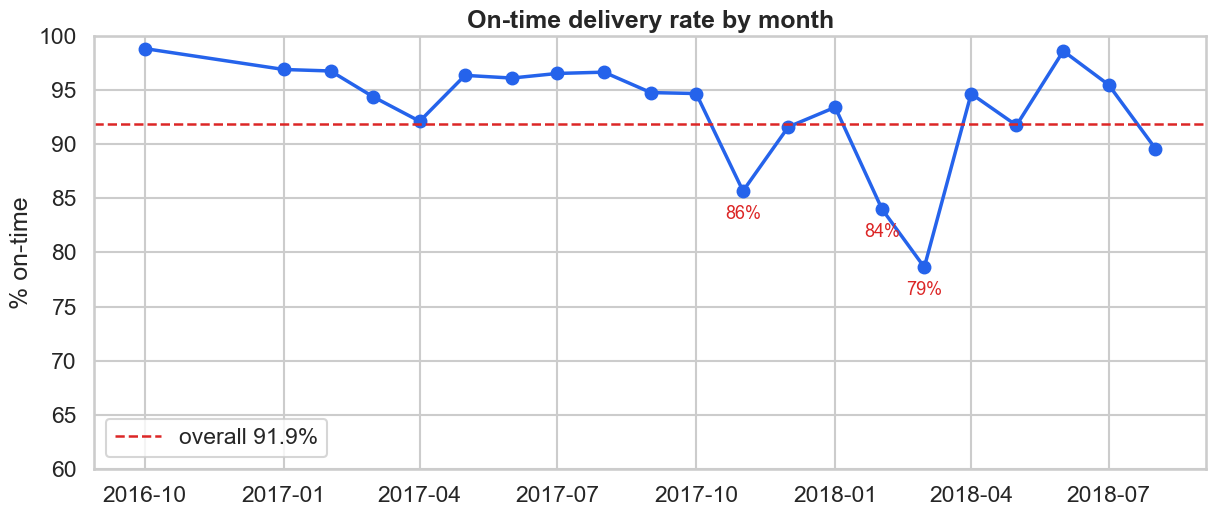

order_month  on_time_pct
 2018-03-01    78.637727
 2018-02-01    84.012204
 2017-11-01    85.688804
 2018-08-01    89.607936


In [8]:
m = metrics.monthly_metrics(orders)
m = m[m.orders >= 100].copy()          # drop tiny cold-start months
m["on_time_pct"] = m.on_time_rate * 100

fig, ax = plt.subplots(figsize=(12.5, 5.5))
ax.plot(m.order_month, m.on_time_pct, color=BLUE, marker="o", lw=2.5)
ax.axhline(delivered.is_late.mean()*-100+100, color=RED, ls="--", lw=1.8,
           label=f"overall {(1-delivered.is_late.mean())*100:.1f}%")
worst3 = m.nsmallest(3, "on_time_pct")
for _, r in worst3.iterrows():
    ax.annotate(f"{r.on_time_pct:.0f}%", (r.order_month, r.on_time_pct),
                textcoords="offset points", xytext=(0, -20), ha="center", color=RED, fontsize=13)
ax.set_title("On-time delivery rate by month"); ax.set_ylabel("% on-time"); ax.set_ylim(60, 100)
ax.legend(loc="lower left")
plt.tight_layout(); plt.show()
print(m[["order_month", "on_time_pct"]].nsmallest(4, "on_time_pct").to_string(index=False))

**Read:** on-time rate holds in the low-90s for most of the window, then buckles in three consecutive
stress points: **Nov 2017 (85.7% — the Black Friday order surge), Feb 2018 (84.0%), and Mar 2018 (78.6%
— the worst month, nearly 1 in 5 late).** These are backlog signatures: demand spikes (Black Friday)
and early-2018 volume overwhelmed fulfilment capacity, and the promised-vs-actual cushion from section 4
wasn't enough to absorb it. The leak is worst exactly when volume is highest — the most expensive time
to disappoint a customer.

---

## Key Takeaways (funnel)

1. **The order pipeline is healthy.** 98.2% of orders that enter the lifecycle reach `delivered`, and
   only **1.24%** are ever truly lost to cancellation/unavailability. There is no cliff in the status
   funnel — the classic "where do orders die?" question has a boring answer here.
2. **The real leak is late delivery — ~8.1%** of delivered orders miss their (already padded) promise.
   That is ~6x the cancellation rate, and unlike a cancellation it bills the customer *and* disappoints
   them.
3. **The leak is concentrated, not uniform.** Late rate ranges from ~5% in the São Paulo core to
   **19.7% in Maranhão**, rises monotonically with freight cost (6.0% → 9.2%), and collapses in backlog
   months (**Mar 2018 = 78.6%**). Root cause: long-haul logistics far from the seller base, plus
   capacity crunches at peak volume.
4. **This sets up notebook 06.** If ~8% of deliveries land late and lateness clusters in distant states
   and backlog months, the natural next question is *what does that do to reviews?* — which is exactly
   the drop we investigate next.